# 🚀 YOLO Trainer - Enhanced with SAHI, Callbacks & Metrics

Notebook for training the YOLO model with comprehensive features:
- ✅ Auto environment detection (Colab/Local)
- ✅ Custom callbacks (EarlyStopping, ModelCheckpoint)
- ✅ Comprehensive metrics evaluator (sklearn-powered)
- ✅ Auto history saving & tracking
- ✅ **SAHI Integration** (Offline slicing for Train/Val, Online slicing for Test)
- ✅ Ready for "Run All"

### 💡 Note on 4K Image Handling (Direct vs SAHI)
YOLO natively resizes/downscales input images to `IMG_SIZE` (e.g. 640 or 960) during training and inference. **It will not throw an error** if you feed it raw 4K images, but you will lose fine details. 
- **Direct 4K Training**: You can input a dataset containing 4K images directly. YOLO will auto-downscale them.
- **SAHI Training**: You feed YOLO a dataset that has been offline-sliced into smaller patches (e.g., 640x640) so no detail is lost.

**Quick Start:**
1. Edit configuration in the next cell (`VERSION`, `RUNNER_NAME`, etc.)
2. Choose inference mode (with or without SAHI) using `USE_SAHI_FOR_TEST`
3. Click "Run All Cells" or execute cell-by-cell
4. Training results are automatically saved in `training_history.txt`

## ⚙️ Training Configuration

**Adjust the following parameters before training:**

In [1]:
# ==========================================
# 📝 MAIN CONFIGURATION - EDIT HERE!
# ==========================================

from pathlib import Path


# ----- DATASET CONFIGURATION -----
VERSION = "Batch3and4_YOLO"  # Dataset folder name

# Auto-detect environment (Colab vs Local)
def detect_environment():
    try:
        import google.colab
        return 'colab'
    except:
        return 'local'

ENV = detect_environment()

# Set dataset root based on environment
if ENV == 'colab':
    DATASET_ROOT = Path(f'/content/drive/MyDrive/Colab Notebooks/TA_CuttingRockDescription/datasets/{VERSION}')
else:  # local
    DATASET_ROOT = Path.home() / "projects" / "DwiAnggara" / "Datasets" / VERSION

DATASET_YAML = DATASET_ROOT / "data.yaml"


# ----- TRAINING CONFIGURATION -----
RUNNER_NAME = "YOLO26m_Batch4_March_Dataset_1024"  # Experiment name (for saving results)
TARGET_EPOCHS = 150  # Maximum number of epochs
IMG_SIZE = 1024  # Input image size
BATCH_SIZE = 16  # Manually set to 16 (bypassing broken YOLO AutoBatch)
WORKERS = 2     # Reduced from 8 to 2 threads to prevent Linux OOM Killer on system RAM
PATIENCE = 50  # Early stopping patience (stop if no improvement after N epochs)

# ----- MODEL CONFIGURATION -----
YOLO_MODEL = "yolo26m-seg.pt"  # Model will be downloaded automatically
YOLO_MODEL_URL = ""
SINGLE_CLASS = False  # Set True if dataset has only 1 class

# ----- SAHI TESTING CONFIGURATION -----
USE_SAHI_FOR_TEST = False # Set to True to use SAHI online slicing for the testing phase on 4K images
SAHI_SLICE_SIZE = 640 # Online slicing size
SAHI_OVERLAP = 0.2  # Online slicing overlap ratio

# ----- HISTORY CONFIGURATION -----
HISTORY_NAME = "history_yolo26m_batch4_march_dataset_1024"  # Name for saving in training_history.txt

print("=" * 60)
print("🎯 TRAINING CONFIGURATION")
print("=" * 60)
print(f"Environment:     {ENV.upper()}")
print(f"Dataset:         {VERSION}")
print(f"Dataset Root:    {DATASET_ROOT}")
print(f"Runner Name:     {RUNNER_NAME}")
print(f"Epochs:          {TARGET_EPOCHS}")
print(f"Batch Size:      {BATCH_SIZE}")
print(f"Workers (CPU):   {WORKERS}")
print(f"Image Size:      {IMG_SIZE}")
print(f"Use SAHI Test:   {USE_SAHI_FOR_TEST}")
print(f"History Name:    {HISTORY_NAME}")
print("=" * 60)

🎯 TRAINING CONFIGURATION
Environment:     LOCAL
Dataset:         Batch3and4_YOLO
Dataset Root:    /home/praktikan/projects/DwiAnggara/Datasets/Batch3and4_YOLO
Runner Name:     YOLO26m_Batch4_March_Dataset_1024
Epochs:          150
Batch Size:      16
Workers (CPU):   2
Image Size:      1024
Use SAHI Test:   False
History Name:    history_yolo26m_batch4_march_dataset_1024


## 📦 Import Libraries

In [2]:
import gc
import torch
import time

In [3]:
!pip install ultralytics scikit-learn pyyaml tqdm pandas matplotlib sahi

In [4]:
from ultralytics import YOLO
import yaml
import torch
import cv2
from pathlib import Path
from sahi.predict import get_sliced_prediction
from sahi import AutoDetectionModel

## 🔧 Custom Callbacks for YOLO Training

Implementing callbacks for:
- **EarlyStopping**: Stop training if there is no improvement
- **ModelCheckpoint**: Automatically save the best model
- **Metrics Tracker**: Record per-epoch metrics for evaluation

In [5]:
# Custom Callbacks for Enhanced YOLO Training
from ultralytics.utils import callbacks
import numpy as np
import torch
import gc

class YOLOCallbackManager:
    """
    Manager for custom YOLO callbacks implementing Early Stopping,
    Metrics Tracking, and aggressive Memory Management.
    """
    def __init__(self, patience=50, monitor='metrics/mAP50-95(M)', mode='max', min_delta=0.001):
        self.patience = patience
        self.monitor = monitor
        self.mode = mode
        self.min_delta = min_delta
        self.best_value = -np.inf if mode == 'max' else np.inf
        self.wait = 0
        self.stopped_epoch = 0
        self.stop_training = False
        
        # History tracking structure
        self.history = {
            'epoch': [],
            'train_loss': [],
            'val_mAP50': [],
            'val_mAP50_95': [],
            'val_precision': [],
            'val_recall': [],
            'val_f1': [],
            'learning_rate': [],
            'gpu_mem_gb': []
        }
        
    def on_train_epoch_end(self, trainer):
        """Callback executed at the end of each training epoch"""
        epoch = trainer.epoch + 1
        metrics = trainer.metrics
        
        # Calculate F1-Score (2 * (precision * recall) / (precision + recall))
        precision = metrics.get('metrics/precision(M)', 0)
        recall = metrics.get('metrics/recall(M)', 0)
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        # Save to history
        self.history['epoch'].append(epoch)
        self.history['train_loss'].append(trainer.loss.item() if hasattr(trainer.loss, 'item') else 0)
        self.history['val_mAP50'].append(metrics.get('metrics/mAP50(M)', 0))
        self.history['val_mAP50_95'].append(metrics.get('metrics/mAP50-95(M)', 0))
        self.history['val_precision'].append(precision)
        self.history['val_recall'].append(recall)
        self.history['val_f1'].append(f1_score)
        self.history['learning_rate'].append(trainer.optimizer.param_groups[0]['lr'])
        
        if torch.cuda.is_available():
            self.history['gpu_mem_gb'].append(torch.cuda.memory_reserved() / 1E9)
        else:
            self.history['gpu_mem_gb'].append(0.0)
        
        # Get current monitored value
        if self.monitor == 'metrics/mAP50-95(M)':
            current = metrics.get('metrics/mAP50-95(M)', 0)
        elif self.monitor == 'metrics/mAP50(M)':
            current = metrics.get('metrics/mAP50(M)', 0)
        else:
            current = 0
        
        # Early stopping logic
        if self.mode == 'max':
            if current > self.best_value + self.min_delta:
                self.best_value = current
                self.wait = 0
                print(f"✅ Epoch {epoch}: {self.monitor} improved to {current:.4f}")
            else:
                self.wait += 1
                print(f"⏳ Epoch {epoch}: {self.monitor} did not improve ({current:.4f} vs best {self.best_value:.4f}), patience {self.wait}/{self.patience}")
        
        # Check if should stop
        if self.wait >= self.patience:
            self.stopped_epoch = epoch
            self.stop_training = True
            print(f"🛑 Early stopping triggered at epoch {epoch}")
            trainer.stop = True  # Signal YOLO to stop training
            
        # --- MEMORY OPTIMIZATION: Aggressive Garbage Collection ---
        # Flushes unused PyTorch / Python cache on CPU and GPU strictly after each epoch
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# Global callback manager instance
callback_manager = None

def setup_yolo_callbacks(model, patience=50, monitor='metrics/mAP50-95(M)'):
    """
    Setup custom callbacks for YOLO model
    """
    global callback_manager
    callback_manager = YOLOCallbackManager(patience=patience, monitor=monitor)
    
    # Register callback
    model.add_callback("on_train_epoch_end", callback_manager.on_train_epoch_end)
    
    print(f"✅ Callbacks configured:")
    print(f"   - Early Stopping: patience={patience}, monitor={monitor}")
    print(f"   - Model Checkpoint: enabled (automatic by YOLO)")
    print(f"   - Metrics Tracking & Memory Flush: enabled (prevents OOM)")
    
    return callback_manager

print("✅ YOLOCallbackManager loaded successfully!")

✅ YOLOCallbackManager loaded successfully!


## 📊 Metrics Evaluator

Functions for calculating and evaluating:
- **Precision**: Prediction accuracy (TP / (TP + FP))
- **Recall**: Model sensitivity (TP / (TP + FN))  
- **F1-Score**: Harmonic mean of Precision & Recall
- **Average IoU**: Average Intersection over Union for segmentation masks

In [6]:
# Enhanced Metrics Evaluator using library
import cv2
import numpy as np
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score
import torch
import os
import pandas as pd

def evaluate_model_metrics(model, dataset_yaml_path, split='test', conf_threshold=0.25, iou_threshold=0.5, use_sahi=False):
    """
    Comprehensive evaluation of YOLO model using native validation.
    Quantitative metrics are evaluated on the provided dataset split.
    If the dataset was offline-sliced for SAHI, this natively calculates sliced metrics.
    
    Args:
        model: YOLO model instance
        dataset_yaml_path: Path to data.yaml
        split: 'test', 'val', or 'train'
        conf_threshold: Confidence threshold for detection
        iou_threshold: IoU threshold to match GT with predictions
        use_sahi: Evaluation mode flag (affects labels in reports)
    
    Returns:
        dict: Dictionary containing all metrics
    """
    print(f"\n{'='*60}")
    print(f"🔍 EVALUATING MODEL ON {split.upper()} SET")
    if use_sahi:
        print(f"⚠️ Note: Quantitative metrics use YOLO native validation on the test set.")
        print(f"          If your dataset is offline-sliced, these metrics accurately reflect SAHI performance.")
    print(f"{'='*60}\n")
    
    metrics_dict = {}

    print("🚀 Running validation to extract native metrics...")
    results = model.val(data=dataset_yaml_path, split=split, conf=conf_threshold, verbose=False)
    
    # Extract metrics from YOLO validation results
    # Box metrics (detection)
    if hasattr(results, 'box') and results.box is not None:
        metrics_dict['precision'] = float(results.box.mp) if hasattr(results.box, 'mp') else 0.0
        metrics_dict['recall'] = float(results.box.mr) if hasattr(results.box, 'mr') else 0.0
        metrics_dict['mAP50'] = float(results.box.map50) if hasattr(results.box, 'map50') else 0.0
        metrics_dict['mAP50_95'] = float(results.box.map) if hasattr(results.box, 'map') else 0.0
    
    # Segmentation metrics
    if hasattr(results, 'seg') and results.seg is not None:
        metrics_dict['mask_mAP50'] = float(results.seg.map50) if hasattr(results.seg, 'map50') else 0.0
        metrics_dict['mask_mAP50_95'] = float(results.seg.map) if hasattr(results.seg, 'map') else 0.0
        metrics_dict['mask_precision'] = float(results.seg.mp) if hasattr(results.seg, 'mp') else 0.0
        metrics_dict['mask_recall'] = float(results.seg.mr) if hasattr(results.seg, 'mr') else 0.0
        
    # --- Speed (Latency / FPS) and TP/FP/FN Extraction ---
    metrics_dict['latency'] = 0.0
    metrics_dict['fps'] = 0.0
    if hasattr(results, 'speed'):
        speed = results.speed
        latency = speed.get('preprocess', 0) + speed.get('inference', 0) + speed.get('postprocess', 0)
        metrics_dict['latency'] = latency
        metrics_dict['fps'] = 1000.0 / latency if latency > 0 else 0.0
        
    metrics_dict['TP'] = 0
    metrics_dict['FP'] = 0
    metrics_dict['FN'] = 0
    if hasattr(results, 'confusion_matrix') and results.confusion_matrix is not None:
        try:
            cm = results.confusion_matrix.matrix
            tp = np.diag(cm)
            fn = cm.sum(axis=1) - tp
            fp = cm.sum(axis=0) - tp
            # Last class acts as background, exclude it from counts
            metrics_dict['TP'] = int(tp[:-1].sum())
            metrics_dict['FP'] = int(fp[:-1].sum())
            metrics_dict['FN'] = int(fn[:-1].sum())
        except Exception as e:
            print(f"⚠️ Could not parse confusion matrix: {e}")

    # Calculate F1-Score using sklearn for consistency
    # Use mask metrics as primary if available, fallback to box
    if 'mask_precision' in metrics_dict:
        metrics_dict['precision'] = metrics_dict['mask_precision']
        metrics_dict['recall'] = metrics_dict['mask_recall']
        
    p, r = metrics_dict.get('precision', 0.0), metrics_dict.get('recall', 0.0)
    metrics_dict['f1_score'] = float(2 * (p * r) / (p + r)) if (p + r) > 0 else 0.0
    
    # Estimate avg IoU from mAP (approximation)
    if 'mask_mAP50' in metrics_dict:
        metrics_dict['avg_iou'] = metrics_dict['mask_mAP50']
    else:
        metrics_dict['avg_iou'] = metrics_dict.get('mAP50', 0.0)
        
    # Print results summary table
    print(f"\n{'='*60}")
    print(f"📊 SUMMARY PERFORMANCE TABLE")
    print(f"{'='*60}")
    
    model_name = "YOLO (SAHI/Sliced)" if use_sahi else "YOLO (Standard)"
    
    df_metrics = pd.DataFrame([{
        "Model": model_name,
        "FPS": f"{metrics_dict.get('fps', 0):.2f}",
        "Latency (ms)": f"{metrics_dict.get('latency', 0):.2f}",
        "F1-Score": f"{metrics_dict.get('f1_score', 0)*100:.2f}%",
        "Precision": f"{metrics_dict.get('precision', 0)*100:.2f}%",
        "Recall": f"{metrics_dict.get('recall', 0)*100:.2f}%",
        "Avg Pixel IoU": f"{metrics_dict.get('avg_iou', 0)*100:.2f}%",
        "TP": metrics_dict.get('TP', '-'),
        "FP": metrics_dict.get('FP', '-'),
        "FN": metrics_dict.get('FN', '-')
    }])
    
    # Format to requested presentation (tabs instead of aligned strings for simple copy paste)
    print(df_metrics.to_string(index=False))
    
    print(f"\n{'='*60}")
    print(f"📊 DETAILED EVALUATION METRICS")
    print(f"{'='*60}")
    print(f"  Precision:     {metrics_dict.get('precision', 0)*100:.2f}%")
    print(f"  Recall:        {metrics_dict.get('recall', 0)*100:.2f}%")
    print(f"  F1-Score:      {metrics_dict.get('f1_score', 0)*100:.2f}%")
    print(f"  Avg IoU:       {metrics_dict.get('avg_iou', 0)*100:.2f}%")
    if 'mask_mAP50' in metrics_dict:
        print(f"  Mask mAP50:    {metrics_dict.get('mask_mAP50', 0)*100:.2f}%")
        print(f"  Mask mAP50-95: {metrics_dict.get('mask_mAP50_95', 0)*100:.2f}%")
    print(f"{'='*60}\n")
    
    return metrics_dict

print("✅ Enhanced Metrics Evaluator loaded!")

✅ Enhanced Metrics Evaluator loaded!


## 💾 History Saving & Management

Functions to:
- Save training history to a `.txt` file
- Load history from a file for comparison
- Update existing history with new results

In [7]:
# History Management for YOLO Training
import os
import ast
from datetime import datetime

HISTORY_FILE = "training_history.txt"

def save_history(history_dict, experiment_name, history_file=HISTORY_FILE):
    """
    Saves training history to a .txt file
    
    Args:
        history_dict: Dictionary containing metrics (precision, recall, f1, iou, etc)
        experiment_name: Name of the experiment (e.g., 'history_1', 'history_baseline')
        history_file: Path to history file (default: training_history.txt)
    """
    # Create directory if it doesn't exist
    os.makedirs(os.path.dirname(history_file) if os.path.dirname(history_file) else '.', exist_ok=True)
    
    # Format timestamp
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    # Prepare history string
    history_str = f"{experiment_name} = {history_dict}"
    
    # Check if file exists
    if os.path.exists(history_file):
        # Read existing content
        with open(history_file, 'r', encoding='utf-8') as f:
            content = f.read()
        
        # Check if experiment already exists
        if f"{experiment_name} = " in content:
            # Update existing experiment
            lines = content.split('\n')
            new_lines = []
            updated = False
            
            for line in lines:
                if line.strip().startswith(f"{experiment_name} = "):
                    new_lines.append(f"# Updated: {timestamp}")
                    new_lines.append(history_str)
                    updated = True
                elif updated and line.startswith('#'):
                    continue  # Skip old timestamp
                else:
                    new_lines.append(line)
            
            content = '\n'.join(new_lines)
            print(f"✅ Updated existing experiment: {experiment_name}")
        else:
            # Append new experiment
            content += f"\n\n# Saved: {timestamp}\n{history_str}"
            print(f"✅ Saved new experiment: {experiment_name}")
    else:
        # Create new file
        content = f"# YOLO Training History Log\n# Created: {timestamp}\n\n{history_str}"
        print(f"✅ Created new history file: {history_file}")
        print(f"✅ Saved experiment: {experiment_name}")
    
    # Write to file
    with open(history_file, 'w', encoding='utf-8') as f:
        f.write(content)
    
    print(f"📁 History saved to: {os.path.abspath(history_file)}")

def load_history(experiment_name, history_file=HISTORY_FILE):
    """
    Load history from file for a specific experiment
    
    Args:
        experiment_name: Name of the experiment to load
        history_file: Path to history file
        
    Returns:
        dict: History dictionary or None if not found
    """
    if not os.path.exists(history_file):
        print(f"❌ History file not found: {history_file}")
        return None
    
    with open(history_file, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Parse file to find experiment
    lines = content.split('\n')
    for line in lines:
        if line.strip().startswith(f"{experiment_name} = "):
            try:
                # Extract dictionary part
                dict_str = line.split(' = ', 1)[1]
                history = ast.literal_eval(dict_str)
                print(f"✅ Loaded experiment: {experiment_name}")
                return history
            except Exception as e:
                print(f"❌ Error parsing history: {e}")
                return None
    
    print(f"❌ Experiment '{experiment_name}' not found in history file")
    return None

def load_all_histories(history_file=HISTORY_FILE):
    """
    Load all histories from file
    
    Returns:
        dict: Dictionary with key = experiment name, value = history dict
    """
    if not os.path.exists(history_file):
        print(f"❌ History file not found: {history_file}")
        return {}
    
    with open(history_file, 'r', encoding='utf-8') as f:
        content = f.read()
    
    histories = {}
    lines = content.split('\n')
    
    for line in lines:
        if ' = {' in line and not line.strip().startswith('#'):
            try:
                # Extract name and dict
                parts = line.split(' = ', 1)
                if len(parts) == 2:
                    name = parts[0].strip()
                    dict_str = parts[1]
                    histories[name] = ast.literal_eval(dict_str)
            except Exception as e:
                continue
    
    print(f"✅ Loaded {len(histories)} experiments from history file")
    return histories

def create_summary_from_callback(callback_manager, final_metrics=None):
    """
    Creates a summary dictionary from callback manager and final metrics
    
    Args:
        callback_manager: YOLOCallbackManager instance
        final_metrics: Optional final metrics dictionary from evaluation
        
    Returns:
        dict: Ready-to-save summary
    """
    history = callback_manager.history
    
    # Get final values (last epoch)
    summary = {
        'train_loss': history['train_loss'],
        'val_mAP50': history['val_mAP50'],
        'val_mAP50_95': history['val_mAP50_95'],
        'val_precision': history['val_precision'],
        'val_recall': history['val_recall'],
        'val_f1': history['val_f1'],
        'learning_rate': history['learning_rate'],
    }
    
    # Add final metrics if provided
    if final_metrics:
        summary['final_precision'] = final_metrics.get('precision', 0)
        summary['final_recall'] = final_metrics.get('recall', 0)
        summary['final_f1'] = final_metrics.get('f1_score', 0)
        summary['final_iou'] = final_metrics.get('avg_iou', 0)
    
    return summary

print("✅ History Management loaded successfully!")

✅ History Management loaded successfully!


## ▶️ Run Training

Run the cell below to start training:

In [8]:
# ==========================================
# 🚀 MAIN TRAINING FUNCTION
# ==========================================

import urllib.request
import os

def download_model_if_needed(model_path, model_url):
    """Download YOLO model from URL if not already present."""
    if not os.path.exists(model_path):
        if model_url:
            print(f"📥 Downloading model from {model_url}...")
            urllib.request.urlretrieve(model_url, model_path)
            print(f"✅ Model downloaded to {model_path}")
        else:
            print(f"📥 Letting Ultralytics auto-download official model: {model_path}")
    else:
        print(f"✅ Model already exists: {model_path}")

def run_training():
    """
    Main training function integrating callbacks, metrics, history saving, 
    and aggressive memory handling to prevent VS Code Window Crashes.
    """
    print("\n" + "=" * 80)
    print("🚀 STARTING YOLO TRAINING")
    print("=" * 80 + "\n")
    
    # 1. Setup output directory
    OUTPUT_DIR = DATASET_ROOT / "models" / RUNNER_NAME
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    # 2. Download model if needed
    download_model_if_needed(YOLO_MODEL, YOLO_MODEL_URL)
    
    # 3. Initialize model
    print(f"🔧 Loading model: {YOLO_MODEL}")
    model = YOLO(YOLO_MODEL)
    
    # 4. Setup callbacks (EarlyStopping + Metrics Tracking + Garbage Collector)
    print(f"⚙️ Setting up callbacks...")
    callback_mgr = setup_yolo_callbacks(model, patience=PATIENCE)
    
    # 5. Clear GPU cache before training
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        import gc
        gc.collect()
        print(f"🔥 GPU: {torch.cuda.get_device_name(0)}")
        print(f"💾 VRAM Available: {torch.cuda.get_device_properties(0).total_memory / 1E9:.2f} GB")
    elif ENV != 'colab':
        print("⚠️ Warning: CUDA not available. Training on CPU will be highly inefficient.")
    
    # 6. Start training
    print(f"🎯 Training: {RUNNER_NAME}")
    print(f"📊 Epochs: {TARGET_EPOCHS}, Batch: {BATCH_SIZE}, Image Size: {IMG_SIZE}\n")
    
    # --- VS CODE OOM CRASH PREVENTION ---
    # VS Code renderer crashes (Code 9) when evaluating thousands of lines from tqdm progress bars over 100+ epochs.
    # Disabling tqdm and limiting verbosity forces the logging to be clean and light on memory.
    os.environ['TQDM_DISABLE'] = '1'
    os.environ['YOLO_VERBOSE'] = 'False'
    
    results = model.train(
        data=DATASET_YAML,
        project=os.path.dirname(OUTPUT_DIR),
        name=os.path.basename(OUTPUT_DIR),
        epochs=TARGET_EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        patience=PATIENCE,
        single_cls=SINGLE_CLASS,
        exist_ok=True,
        device=0 if torch.cuda.is_available() else 'cpu',
        val=True,
        
        # --- MEMORY AND PROCESS OPTIMIZATION PARAMETERS FOR 3000 IMAGES ---
        amp=True,                # Uses Automatic Mixed Precision (saves VRAM)
        workers=WORKERS,         # Reduced CPU multi-threading to prevent PyTorch RAM leaks 
        retina_masks=True,
        cache=False,             # Strictly disable caching images to RAM, rely on NVMe SSD
        verbose=False,           # Suppress large console outputs to avoid VS Code Extension Host OOM
        plots=True               # Still generate evaluation matplotlib plots directly to SSD
    )
    
    # 7. Evaluate model on test set
    print("\n" + "=" * 80)
    print("📊 EVALUATING MODEL ON TEST SET")
    print("=" * 80 + "\n")
    
    final_metrics = evaluate_model_metrics(
        model=model,
        dataset_yaml_path=DATASET_YAML,
        split='test',
        conf_threshold=0.25,
        iou_threshold=0.5,
        use_sahi=USE_SAHI_FOR_TEST
    )
    
    # 8. Create history summary from callback
    print("\n💾 Saving training history...")
    history_summary = create_summary_from_callback(callback_mgr, final_metrics)
    
    # 9. Save history to file
    save_history(history_summary, HISTORY_NAME)
    
    # 10. Final summary
    print("\n" + "=" * 80)
    print("✅ TRAINING COMPLETED SUCCESSFULLY!")
    print("=" * 80)
    print(f"📁 Model saved to:    {OUTPUT_DIR}")
    print(f"📊 History saved as:  {HISTORY_NAME}")
    print(f"📄 History file:      training_history.txt")
    print(f"\n🏆 Final Test Metrics:")
    print(f"   Precision: {final_metrics.get('precision', 0)*100:.2f}%")
    print(f"   Recall:    {final_metrics.get('recall', 0)*100:.2f}%")
    print(f"   F1-Score:  {final_metrics.get('f1_score', 0)*100:.2f}%")
    print(f"   Avg IoU:   {final_metrics.get('avg_iou', 0)*100:.2f}%")
    print("=" * 80 + "\n")
    
    # Clear GPU cache and Force Collect remaining memory variables
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        import gc
        gc.collect()
    
    return model, callback_mgr, final_metrics

# Run training
print("🔄 Ready to train! Run the cell below to start training.")

🔄 Ready to train! Run the cell below to start training.


In [9]:
# Run training
model, callback_manager, final_metrics = run_training()

print("\n✅ Training complete! Check training_history.txt to see the results.")


🚀 STARTING YOLO TRAINING

✅ Model already exists: yolo26m-seg.pt
🔧 Loading model: yolo26m-seg.pt
⚙️ Setting up callbacks...
✅ Callbacks configured:
   - Early Stopping: patience=50, monitor=metrics/mAP50-95(M)
   - Model Checkpoint: enabled (automatic by YOLO)
   - Metrics Tracking & Memory Flush: enabled (prevents OOM)
🔥 GPU: NVIDIA GeForce RTX 5080
💾 VRAM Available: 16.61 GB
🎯 Training: YOLO26m_Batch4_March_Dataset_1024
📊 Epochs: 150, Batch: 16, Image Size: 1024

New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.35 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 15842MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/praktikan/projects/DwiAnggara/Datasets/B

## ⚙️ Hyperparameter Tuning Strategy: From "Trial-and-Error" to "Directed Evolution"

For efficiency, brute-force methods like Grid Search are highly discouraged because they are extremely time-consuming (e.g., 30 minutes per trial). Our focus is on smarter methods:

*   **Genetic Evolution**: A built-in method in Ultralytics `model.tune()` that works like natural selection. It generates an initial "population" of random hyperparameter combinations, and the best ones "breed" and "mutate" to create better combinations in the next generation.
*   **Bayesian Optimization**: A highly efficient option ideal for this case. This method builds a probabilistic model to "learn" which areas of the search space are most promising, finding the optimal combination in significantly fewer trials. Accessible via integration with Ray Tune or Optuna.

📊 Search Space: Key Parameters for Fast Tuning

You don't need to tweak every parameter. Prioritize those with the highest impact to save time. Here's a recommended search space based on official Ultralytics guidelines, optimized for efficiency:

| Category | Parameter | Default Range | Notes & Efficiency Recommendations |
| :--- | :--- | :--- | :--- |
| **Optimization** | `lr0` (Initial LR) | `1e-5` - `1e-2` | **High Priority**. Start from `1e-4` for fine-tuning. |
| | `momentum` | `0.7` - `0.98` | **Low Priority**. The default value (0.937) is generally optimal. |
| | `weight_decay` | `0.0` - `0.001` | **Medium Priority**. Helps prevent overfitting, especially on small datasets. |
| **Augmentation** | `hsv_h`, `hsv_s`, `hsv_v` | `0.0` - `0.1` (Hue)<br>`0.0` - `0.9` (Sat/Val) | **High Priority for Rocks**. Color variations are crucial for distinguishing similar rock classes. |
| | `degrees` (Rotation) | `0.0` - `45.0` | **Low Priority**. Small rotations (5-10 degrees) might help, but aren't critical. |
| | `mosaic` | `0.0` - `1.0` | **Medium Priority**. Useful, but should be disabled toward the end of training (`close_mosaic=10`). |
| **Other** | `box`, `cls` (Loss weights) | `1.0` - `20.0` (Box)<br>`0.1` - `4.0` (Cls) | **Medium/High Priority**. If there's class imbalance, increase `cls` to penalize classification errors more heavily. |

### Integration with Optuna (Sequential Bayesian Optimization)

Optuna is highly recommended for environments with constrained resources (VRAM/RAM). Unlike aggressive parallel frameworks, Optuna runs sequentially which allows strict control over memory management (garbage collection) between trials.

💡 Additional Tips for Efficiency
*   **Sequential Runs**: Trials run one after another. If a trial hits a memory limit, Optuna can catch it gracefully and skip parameter ranges causing issues.
*   **Reduce Epochs for Tuning**: Use 15-20 epochs per trial during search. Once the best candidate is found, train the final model with full epochs (100-300).
*   **Manage VRAM**: We automatically reduce batch size specifically for tuning to prevent Out-Of-Memory (OOM) errors.

In [ ]:
# ==========================================
# 🧬 SEQUENTIAL HYPERPARAMETER TUNING (OPTUNA)
# ==========================================

import os
import gc
import torch
import optuna
from ultralytics import YOLO

# 🛠️ Enable expandable PyTorch segments to reduce memory fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

def run_optuna_tuning():
    print("\n" + "=" * 80)
    print("🧬 STARTING HYPERPARAMETER TUNING (OPTUNA)")
    print("=" * 80 + "\n")

    # Configurations for Tuning (Highly constrained to prevent OOM)
    TUNE_EPOCHS = 30      # Reduced epochs for fast serial trials
    TUNE_ITERATIONS = 10  # Total number of trials
    TUNE_NAME = f"{RUNNER_NAME}_optuna"
    
    # Safe batch sizing for memory constrained tuning
    tune_batch_size = max(2, BATCH_SIZE // 4)
    print(f"📉 Using severely reduced batch_size: {tune_batch_size} (prevents OOM)")

    def objective(trial):
        print(f"\n🚀 Starting Trial {trial.number}")
        
        # 1. Strict memory clearing BEFORE each trial
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
        # 2. Suggest hyperparameters directly from Optuna
        lr0 = trial.suggest_float("lr0", 1e-5, 1e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 0.0, 0.001)
        hsv_s = trial.suggest_float("hsv_s", 0.3, 0.9)
        hsv_v = trial.suggest_float("hsv_v", 0.3, 0.9)
        
        print(f"📊 Suggested Params -> lr0: {lr0:.6f}, weight_decay: {weight_decay:.6f}, hsv_s: {hsv_s:.2f}, hsv_v: {hsv_v:.2f}")

        # 3. Initialize fresh model
        model = YOLO(YOLO_MODEL)
        
        try:
            # 4. Execute training sequentially
            results = model.train(
                data=DATASET_YAML,
                epochs=TUNE_EPOCHS,
                imgsz=IMG_SIZE,
                batch=tune_batch_size,
                optimizer="AdamW", # Strictly pass optimizer so YOLO respects lr0 and momentum
                lr0=lr0,
                weight_decay=weight_decay,
                hsv_s=hsv_s,
                hsv_v=hsv_v,
                project=str(DATASET_ROOT / "models" / TUNE_NAME),
                name=f"trial_{trial.number}",
                verbose=False,
                plots=False,
                save=False,      # Do not save checkpoints every trial
                workers=2,       # Ensure low thread counts
                device=0 if torch.cuda.is_available() else 'cpu'
            )
            
            # 5. Extract target metric to maximize (mAP50-95 Segmentation, fallback to Box)
            if hasattr(results, 'seg') and results.seg is not None:
                metric = results.seg.map  # map represents mAP50-95
            else:
                metric = results.box.map
                
            return metric
            
        except Exception as e:
            # Gracefully handle CUDA OOM errors without crashing the entire notebook
            print(f"❌ Error during Trial {trial.number}: {str(e)}")
            raise optuna.exceptions.TrialPruned()
            
        finally:
            # 6. Strict memory clearing AFTER each trial
            del model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    # 7. Create and run Optuna study
    study = optuna.create_study(direction="maximize", study_name=TUNE_NAME)
    study.optimize(objective, n_trials=TUNE_ITERATIONS, gc_after_trial=True)
    
    print("\n" + "=" * 80)
    print("✅ OPTUNA TUNING COMPLETED!")
    print("=" * 80)
    print("📂 Best Hyperparameters:")
    for key, value in study.best_params.items():
        print(f"  - {key}: {value}")

    return study.best_params

best_optuna_results = run_optuna_tuning()

[I 2026-04-16 11:44:49,437] A new study created in memory with name: YOLO26m_Batch4_March_Dataset_960_Tuned_Optuna_optuna



🧬 STARTING HYPERPARAMETER TUNING (OPTUNA)

📉 Using severely reduced batch_size: 4 (prevents OOM)

🚀 Starting Trial 0
📊 Suggested Params -> lr0: 0.000125, weight_decay: 0.000247, hsv_s: 0.42, hsv_v: 0.86
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.35 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 15842MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/praktikan/projects/DwiAnggara/Datasets/Batch3and4_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hs

[I 2026-04-16 11:48:42,471] Trial 0 finished with value: 0.30695401706639597 and parameters: {'lr0': 0.00012525125765160748, 'weight_decay': 0.0002466322104657607, 'hsv_s': 0.4153716039120907, 'hsv_v': 0.8604993171067647}. Best is trial 0 with value: 0.30695401706639597.



🚀 Starting Trial 1
📊 Suggested Params -> lr0: 0.000371, weight_decay: 0.000547, hsv_s: 0.45, hsv_v: 0.33
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.35 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 15842MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/praktikan/projects/DwiAnggara/Datasets/Batch3and4_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.45478772313247195, hsv_v=0.33078277207250817, imgsz=960, int8=False, iou=0.7, k

[I 2026-04-16 11:52:24,837] Trial 1 finished with value: 0.31995603245901005 and parameters: {'lr0': 0.00037079185230377257, 'weight_decay': 0.0005471694152547826, 'hsv_s': 0.45478772313247195, 'hsv_v': 0.33078277207250817}. Best is trial 1 with value: 0.31995603245901005.


...


🚀 Starting Trial 8
📊 Suggested Params -> lr0: 0.000866, weight_decay: 0.000295, hsv_s: 0.42, hsv_v: 0.33
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.35 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 15842MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/praktikan/projects/DwiAnggara/Datasets/Batch3and4_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.41869456041555564, hsv_v=0.3274945693694351, imgsz=960, int8=False, iou=0.7, ke

[I 2026-04-16 12:18:25,039] Trial 8 finished with value: 0.31922198485106323 and parameters: {'lr0': 0.0008662456982603658, 'weight_decay': 0.00029485245177467666, 'hsv_s': 0.41869456041555564, 'hsv_v': 0.3274945693694351}. Best is trial 1 with value: 0.31995603245901005.



🚀 Starting Trial 9
📊 Suggested Params -> lr0: 0.000016, weight_decay: 0.000735, hsv_s: 0.76, hsv_v: 0.35
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.35 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 15842MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/praktikan/projects/DwiAnggara/Datasets/Batch3and4_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7618076146392991, hsv_v=0.35392438014843974, imgsz=960, int8=False, iou=0.7, ke

[I 2026-04-16 12:22:07,968] Trial 9 finished with value: 0.1515974397047468 and parameters: {'lr0': 1.6008729134437967e-05, 'weight_decay': 0.0007350579070261607, 'hsv_s': 0.7618076146392991, 'hsv_v': 0.35392438014843974}. Best is trial 1 with value: 0.31995603245901005.



✅ OPTUNA TUNING COMPLETED!
📂 Best Hyperparameters:
  - lr0: 0.00037079185230377257
  - weight_decay: 0.0005471694152547826
  - hsv_s: 0.45478772313247195
  - hsv_v: 0.33078277207250817


## 🚀 Final Training with Optimized Hyperparameters

After tuning is complete, evaluate the extracted best hyperparameters and retrain the model using these strict optimal limits to save training time while maximizing accuracy and segmentation mask contours.

This block correctly updates the experiment tracker namespace to easily distinguish between the previous baseline parameters and these tuned results.

In [9]:
# ==========================================
# 🚀 RETRAIN WITH BEST HYPERPARAMETERS
# ==========================================

import os
import gc
import torch

# 🛠️ Enable expandable PyTorch segments to reduce memory fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

def train_best_model(best_params):
    """
    Reruns the main YOLO training function using the best hyperparameters found from Optuna.
    Note: We manually override the global RUNNER_NAME and HISTORY_NAME to prevent
    overwriting the baseline experiment results.
    """
    global RUNNER_NAME, HISTORY_NAME
    
    print("\n" + "=" * 80)
    print("🚀 STARTING FINAL TRAINING WITH OPTIMIZED PARAMETERS")
    print("=" * 80 + "\n")
    
    # 1. Override Experiment Identifiers
    baseline_runner = RUNNER_NAME
    RUNNER_NAME = f"{baseline_runner}_30_Epochs_Tuned"
    HISTORY_NAME = f"{HISTORY_NAME}_30_epochs_tuned"
    
    print(f"🔄 Switched RUNNER_NAME to: {RUNNER_NAME}")
    print(f"🔄 Switched HISTORY_NAME to: {HISTORY_NAME}")
    
    # 2. Setup Output Directory
    OUTPUT_DIR = DATASET_ROOT / "models" / RUNNER_NAME
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    # 3. Aggressive memory clearing BEFORE loading new model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
        
    # 4. Load Fresh Base Model
    print(f"\n🔧 Loading base model: {YOLO_MODEL}")
    model = YOLO(YOLO_MODEL)
    
    # 5. Setup Callbacks
    callback_mgr = setup_yolo_callbacks(model, patience=PATIENCE)
    
    print(f"\n🎯 Training Tuned Model: {RUNNER_NAME}")
    print(f"📊 Extracted Best Parameters -> lr0: {best_params.get('lr0'):.6f}, hsv_s: {best_params.get('hsv_s'):.3f}, hsv_v: {best_params.get('hsv_v'):.3f}")
    
    # Enable TQDM back if you want, but disabled is safer for VS Code stability
    os.environ['TQDM_DISABLE'] = '1'
    os.environ['YOLO_VERBOSE'] = 'False'
    
    # Safe batch size to prevent CUDA OOM across 120 epochs
    safe_batch = 8 if BATCH_SIZE >= 16 else BATCH_SIZE
    print(f"📉 Using reduced batch size: {safe_batch} to prevent CUDA accumulation")
    
    # 6. Execute Final Train
    results = model.train(
        data=best_params.get("data", DATASET_YAML),
        project=os.path.dirname(OUTPUT_DIR),
        name=os.path.basename(OUTPUT_DIR),
        epochs=TARGET_EPOCHS,
        imgsz=IMG_SIZE,
        batch=safe_batch,  
        patience=PATIENCE,
        single_cls=SINGLE_CLASS,
        exist_ok=True,
        device=0 if torch.cuda.is_available() else 'cpu',
        val=True,
        
        # --- Memory Limits ---
        amp=True,
        workers=WORKERS,         
        retina_masks=True,
        cache=False,             
        verbose=False,
        plots=True,
        
        # --- Inject Optuna Best Hyperparameters ---
        optimizer="AdamW", # Strictly pass optimizer so YOLO respects lr0 and momentum
        lr0=best_params.get("lr0"),
        weight_decay=best_params.get("weight_decay"),
        hsv_s=best_params.get("hsv_s"),
        hsv_v=best_params.get("hsv_v")
    )
    
    # 7. Final Evaluation
    print("\n" + "=" * 80)
    print("📊 EVALUATING FINAL TUNED MODEL")
    print("=" * 80 + "\n")
    
    final_metrics = evaluate_model_metrics(
        model=model,
        dataset_yaml_path=DATASET_YAML,
        split='test',
        conf_threshold=0.25,
        iou_threshold=0.5,
        use_sahi=USE_SAHI_FOR_TEST
    )
    
    # 8. Save Final History Summary
    history_summary = create_summary_from_callback(callback_mgr, final_metrics)
    save_history(history_summary, HISTORY_NAME)
    
    print("\n✅ Final Tuned Training complete! Check training_history.txt for insights.")
    return model, final_metrics

# --- Manual override of best parameters exactly as extracted --- 
best_extracted_params = {
  "data": str(DATASET_YAML),
  "hsv_s": 0.45478772313247195,
  "hsv_v": 0.33078277207250817,
  "lr0": 0.00037079185230377257,
  "weight_decay": 0.0005471694152547826
}


final_model, final_metrics = train_best_model(best_extracted_params)


🚀 STARTING FINAL TRAINING WITH OPTIMIZED PARAMETERS

🔄 Switched RUNNER_NAME to: YOLO26m_Batch4_March_Dataset_960_Tuned_Optuna_30_Epochs_Tuned
🔄 Switched HISTORY_NAME to: history_yolo26m_batch4_march_dataset_960_tuned_optuna_30_epochs_tuned

🔧 Loading base model: yolo26m-seg.pt
✅ Callbacks configured:
   - Early Stopping: patience=50, monitor=metrics/mAP50-95(M)
   - Model Checkpoint: enabled (automatic by YOLO)
   - Metrics Tracking & Memory Flush: enabled (prevents OOM)

🎯 Training Tuned Model: YOLO26m_Batch4_March_Dataset_960_Tuned_Optuna_30_Epochs_Tuned
📊 Extracted Best Parameters -> lr0: 0.000371, hsv_s: 0.455, hsv_v: 0.331
📉 Using reduced batch size: 8 to prevent CUDA accumulation
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.35 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 15842MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8

## 💾 Export Model to Local Folder

Save the trained model weights to the `models/` folder in the notebook directory.

In [10]:
# ==========================================
# 💾 EXPORT MODEL TO LOCAL FOLDER
# ==========================================

import shutil
from datetime import datetime

def export_model_to_local(source_model_dir=None, export_folder="models"):
    """
    Export model weights from training results to local directory 'models/'
    
    Args:
        source_model_dir: Path to trained model folder (default: auto from DATASET_ROOT)
        export_folder: Target folder name (default: 'models')
    """
    # Determine source directory
    if source_model_dir is None:
        source_model_dir = f"{DATASET_ROOT}/models/{RUNNER_NAME}"
    
    # Create export folder if it doesn't exist
    local_export_dir = os.path.join(os.getcwd(), export_folder)
    os.makedirs(local_export_dir, exist_ok=True)
    
    # Create subfolder with experiment name and timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    export_subdir = os.path.join(local_export_dir, f"{RUNNER_NAME}_{timestamp}")
    os.makedirs(export_subdir, exist_ok=True)
    
    print("="*60)
    print("💾 EXPORTING MODEL TO LOCAL FOLDER")
    print("="*60)
    print(f"Source:      {source_model_dir}")
    print(f"Destination: {export_subdir}")
    print()
    
    # Copy weights folder
    weights_src = os.path.join(source_model_dir, "weights")
    weights_dst = os.path.join(export_subdir, "weights")
    
    if os.path.exists(weights_src):
        shutil.copytree(weights_src, weights_dst, dirs_exist_ok=True)
        print(f"✅ Copied weights folder: {weights_dst}")
        
        # List files
        weight_files = os.listdir(weights_dst)
        for wf in weight_files:
            file_size = os.path.getsize(os.path.join(weights_dst, wf)) / (1024*1024)  # MB
            print(f"   📦 {wf} ({file_size:.2f} MB)")
    else:
        print(f"⚠️ Weights folder not found: {weights_src}")
    
    # Copy important files
    files_to_copy = [
        "args.yaml",           # Training configuration
        "results.csv",         # Training metrics
        "results.png",         # Training curves
        "confusion_matrix.png",
        "confusion_matrix_normalized.png",
        "F1_curve.png",
        "P_curve.png",
        "R_curve.png",
        "PR_curve.png"
    ]
    
    print("\n📄 Copying result files...")
    for filename in files_to_copy:
        src_file = os.path.join(source_model_dir, filename)
        if os.path.exists(src_file):
            dst_file = os.path.join(export_subdir, filename)
            shutil.copy2(src_file, dst_file)
            print(f"   ✅ {filename}")
    
    # Create info file
    info_file = os.path.join(export_subdir, "model_info.txt")
    with open(info_file, 'w', encoding='utf-8') as f:
        f.write(f"Model Export Info\n")
        f.write(f"="*60 + "\n")
        f.write(f"Experiment Name: {RUNNER_NAME}\n")
        f.write(f"History Name:    {HISTORY_NAME}\n")
        f.write(f"Export Time:     {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Dataset:         {VERSION}\n")
        f.write(f"Epochs:          {TARGET_EPOCHS}\n")
        f.write(f"Batch Size:      {BATCH_SIZE}\n")
        f.write(f"Image Size:      {IMG_SIZE}\n")
        f.write(f"SAHI Testing:    {USE_SAHI_FOR_TEST}\n")
        f.write(f"\nSource Path:\n{source_model_dir}\n")
        f.write(f"\nExport Path:\n{export_subdir}\n")
        f.write(f"="*60 + "\n")
    
    print(f"\n✅ Created model_info.txt")
    
    print("\n" + "="*60)
    print(f"✅ MODEL EXPORTED SUCCESSFULLY!")
    print(f"📁 Location: {export_subdir}")
    print("="*60 + "\n")
    
    return export_subdir

# Execute export
try:
    export_path = export_model_to_local()
    print(f"💡 Tip: Model is saved in 'models/' folder and ready for deployment or backup!")
except Exception as e:
    print(f"❌ Error during export: {e}")
    print(f"💡 Ensure that training has completed and the model was saved successfully.")

💾 EXPORTING MODEL TO LOCAL FOLDER
Source:      /home/praktikan/projects/DwiAnggara/Datasets/Batch3and4_YOLO/models/YOLO26m_Batch4_March_Dataset_1024
Destination: /home/praktikan/projects/github/DwiAnggara/Automatic-Cutting-Description/notebooks/training/models/YOLO26m_Batch4_March_Dataset_1024_20260416_135745

✅ Copied weights folder: /home/praktikan/projects/github/DwiAnggara/Automatic-Cutting-Description/notebooks/training/models/YOLO26m_Batch4_March_Dataset_1024_20260416_135745/weights
   📦 best.pt (52.03 MB)
   📦 last.pt (52.03 MB)

📄 Copying result files...
   ✅ args.yaml
   ✅ results.csv
   ✅ results.png
   ✅ confusion_matrix.png
   ✅ confusion_matrix_normalized.png

✅ Created model_info.txt

✅ MODEL EXPORTED SUCCESSFULLY!
📁 Location: /home/praktikan/projects/github/DwiAnggara/Automatic-Cutting-Description/notebooks/training/models/YOLO26m_Batch4_March_Dataset_1024_20260416_135745

💡 Tip: Model is saved in 'models/' folder and ready for deployment or backup!


In [11]:
def clear_cuda_cache():
    """Clear CUDA GPU memory cache."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        gc.collect()
clear_cuda_cache()
gc.collect()

0

## 👁️ Visualizing Model Predictions (Hollow Contours)

Visualizing the model's predictions on a sample from the *test set*.

Key visualization details:
- **Hollow segmentation**: Only displays the outer boundaries (*no alpha fill*) to match the CVAT annotation style.
- **Class-based Colors**: Color labels mapped specifically for each class.
- **SAHI Integration**: If `USE_SAHI_FOR_TEST` is True, it will use SAHI's online slicing to perform predictions and stitch the masks on the 4K image.

🔍 Loading model: /home/praktikan/projects/github/DwiAnggara/Automatic-Cutting-Description/notebooks/training/models/YOLO26m_Batch4_March_Dataset_960_Tuned_Optuna_30_Epochs_Tuned_20260416_130119/weights/best.pt
👁️ Predicting on: PIC-0028.jpg


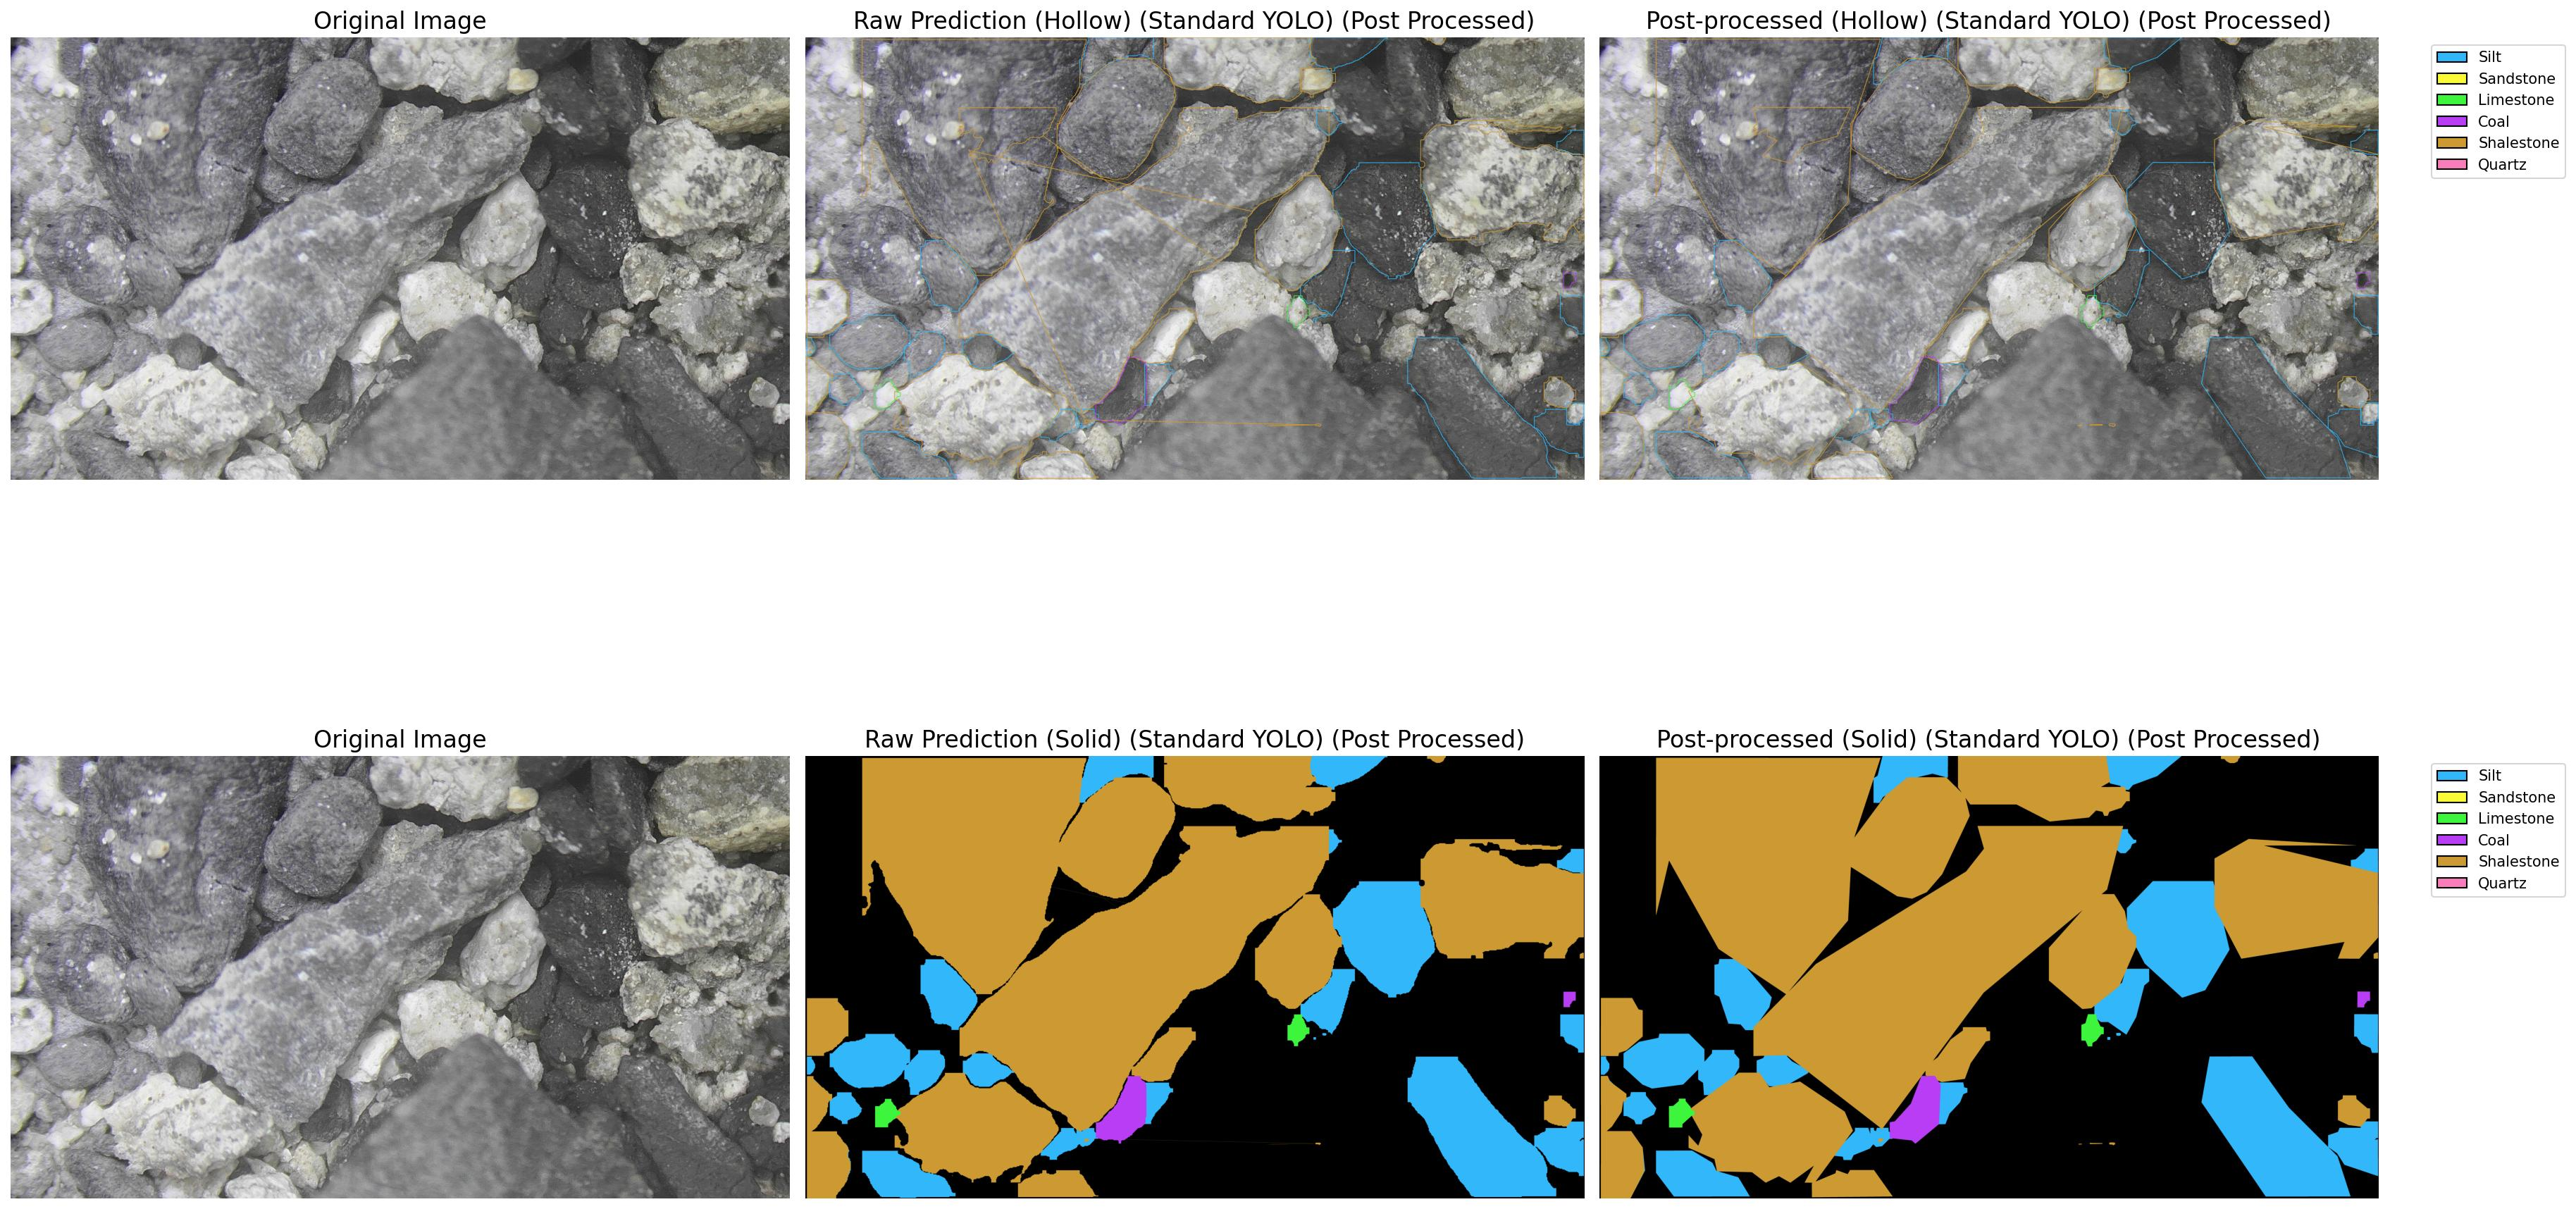

✅ Image saved at: predictions_YOLO26m_Batch4_March_Dataset_960_Tuned_Optuna_30_Epochs_Tuned/prediction_PIC-0028.jpg


In [19]:
import cv2
import random
import matplotlib.pyplot as plt
import numpy as np
import os
import yaml
import sys
from pathlib import Path

# Add root project path to load reusable classes from src.inference
sys.path.append(str(Path(os.path.abspath('')).parent.parent))
from src.inference import MaskPostProcessor, RockVisualizer

def visualize_hollow_segmentation(model_path, images_dir, use_sahi=False, slice_size=640, overlap=0.2):
    """
    Runs inference on a randomly selected image from images_dir.
    Applies post-processing to clean noisy masks and visualizes
    the results using centralized RockVisualizer classes.
    """
    print(f"🔍 Loading model: {model_path}")
    if not os.path.exists(model_path):
        print(f"❌ Model not found at {model_path}. Complete training first!")
        return
        
    sahi_model = None
    yolo_model = None
        
    if use_sahi:
        from sahi import AutoDetectionModel
        import torch
        print(f"🔪 Setting up SAHI (Slice Size: {slice_size}, Overlap: {overlap})")
        sahi_model = AutoDetectionModel.from_pretrained(
            model_type="yolov8",
            model_path=model_path,
            confidence_threshold=0.25,
            device="cuda:0" if torch.cuda.is_available() else "cpu",
        )
    else:
        try:
            from ultralytics import YOLO
            yolo_model = YOLO(model_path)
        except Exception as e:
            print(f"❌ Error loading model: {e}")
            return
        
    # Get random image from directory
    valid_exts = ('.png', '.jpg', '.jpeg')
    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(valid_exts)]
    
    if not image_files:
        print(f"❌ No instances found in {images_dir}")
        return
        
    sample_name = random.choice(image_files)
    img_path = os.path.join(images_dir, sample_name)
    
    # Read image
    print(f"👁️ Predicting on: {sample_name}")
    original_bgr = cv2.imread(img_path)
    
    # Initialize our reusable processors
    post_processor = MaskPostProcessor(min_area=300, epsilon_ratio=0.01, simplify_tol=2.0)
    visualizer = RockVisualizer(thickness=8)
    
    # We will accumulate polygons grouped by class ID
    raw_polygons_by_class = {}
    proc_polygons_by_class = {}
    
    if use_sahi:
        from sahi.predict import get_sliced_prediction
        result = get_sliced_prediction(
            img_path,
            sahi_model,
            slice_height=slice_size,
            slice_width=slice_size,
            overlap_height_ratio=overlap,
            overlap_width_ratio=overlap,
            verbose=False
        )
        
        for obj in result.object_prediction_list:
            if obj.mask is not None:
                mask_polygon = obj.mask.bool_mask
                class_id_int = obj.category.id
                
                # Fetch raw boundary points manually if we wanted, but SAHI returns boolean masks 
                # directly so we will bypass raw polygon plotting for SAHI directly returning boolean 
                clean_polys = post_processor.process(mask_polygon)
                
                if class_id_int not in proc_polygons_by_class:
                    proc_polygons_by_class[class_id_int] = []
                proc_polygons_by_class[class_id_int].extend(clean_polys)
                
    else:
        # Native YOLO prediction
        results = yolo_model.predict(img_path, conf=0.25, verbose=False)[0]
        
        if results.masks is not None:
            # We use xy coordinates instead of masks.data padding for robust postprocessing
            mask_xys = results.masks.xy
            class_ids = results.boxes.cls.cpu().numpy()
            
            h, w = original_bgr.shape[:2]
            
            for mask_xy, cls_id in zip(mask_xys, class_ids):
                class_id_int = int(cls_id)
                
                if len(mask_xy) > 2:
                    mask_xy_int = mask_xy.astype(np.int32)
                    
                    if class_id_int not in raw_polygons_by_class:
                        raw_polygons_by_class[class_id_int] = []
                    raw_polygons_by_class[class_id_int].append(mask_xy_int)
                    
                    # Rasterize exactly on original resolution for processing
                    canvas = np.zeros((h, w), dtype=np.uint8)
                    cv2.fillPoly(canvas, [mask_xy_int], 255)
                    
                    # Apply post-processing
                    clean_polys = post_processor.process(canvas)
                    
                    if class_id_int not in proc_polygons_by_class:
                        proc_polygons_by_class[class_id_int] = []
                    proc_polygons_by_class[class_id_int].extend(clean_polys)
                
    
    # Generate Visualizations via RockVisualizer
    proc_hollow = visualizer.draw_hollow(original_bgr, proc_polygons_by_class)
    proc_solid = visualizer.draw_mask_only(original_bgr.shape, proc_polygons_by_class)
    
    from IPython.display import display, Image as IPyImage
    global RUNNER_NAME
    
    out_dir = f"predictions_{RUNNER_NAME}"
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f"prediction_{sample_name}")
    title_suffix = "(SAHI Sliced) (Post Processed)" if use_sahi else "(Standard YOLO) (Post Processed)"
    
    if use_sahi:
        # Ensure plot_comparison works by substituting to plot_advanced_comparison or implemented plot_comparison
        if hasattr(visualizer, "plot_comparison"):
            fig = visualizer.plot_comparison(original_bgr, proc_hollow, proc_solid, title_suffix=title_suffix)
        else:
            # Fallback if the module hasn't propagated the updated method yet in memory
            original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
            fig, axes = plt.subplots(1, 3, figsize=(24, 8))
            axes[0].imshow(original_rgb)
            axes[0].set_title("Original Image", fontsize=16)
            axes[0].axis('off')
            axes[1].imshow(proc_hollow)
            axes[1].set_title(f"Processed (Hollow) {title_suffix}", fontsize=16)
            axes[1].axis('off')
            axes[2].imshow(proc_solid)
            axes[2].set_title(f"Processed (Solid) {title_suffix}", fontsize=16)
            axes[2].axis('off')
            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor=[c/255 for c in color], edgecolor='k', label=visualizer.class_names.get(id, f"ID {id}")) for id, color in visualizer.class_colors.items()]
            axes[2].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.25, 1))
            plt.tight_layout()
    else:
        # Native YOLO exports 2x3 grid
        raw_hollow = visualizer.draw_hollow(original_bgr, raw_polygons_by_class)
        raw_solid = visualizer.draw_mask_only(original_bgr.shape, raw_polygons_by_class)
        fig = visualizer.plot_advanced_comparison(original_bgr, raw_hollow, proc_hollow, raw_solid, proc_solid, title_suffix=title_suffix)
        
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close()
    
    display(IPyImage(out_path))
    print(f"✅ Image saved at: {out_path}")

# Execution:
best_model_weights = os.path.join(export_path, "weights", "best.pt") if 'export_path' in globals() else str(DATASET_ROOT / "models" / RUNNER_NAME / "weights" / "best.pt")

with open(DATASET_YAML, 'r') as f:
    data_cfg = yaml.safe_load(f)
test_dir = data_cfg.get('test', 'test')
if not os.path.isabs(test_dir):
    test_dir = os.path.join(str(DATASET_ROOT), test_dir)
if not test_dir.endswith('images'):
    test_dir = os.path.join(test_dir, 'images')

visualize_hollow_segmentation(
    model_path=best_model_weights, 
    images_dir=test_dir,
    use_sahi=USE_SAHI_FOR_TEST,
    slice_size=SAHI_SLICE_SIZE,
    overlap=SAHI_OVERLAP
)